In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
#plt.style.use('seaborn-darkgrid')
import seaborn as sns

In [2]:
from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import make_forecasting_frame
from sklearn.ensemble import AdaBoostRegressor
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction.settings import ComprehensiveFCParameters
pd.core.common.is_list_like = pd.api.types.is_list_like
import pandas_datareader.data as web
import datetime

In [3]:
import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm

In [4]:
#读入数据
x = pd.read_csv('dataset.csv', sep=',', encoding = 'utf-8')

#查看数据类型
x.dtypes


index_code     object
date           object
open          float64
close         float64
low           float64
high          float64
volume        float64
money         float64
change        float64
label         float64
dtype: object

In [5]:
#查看数据前几行
x.head()


,index_code,date,open,close,low,high,volume,money,change,label
0,sh000001,1990/12/20,104.30,104.39,99.98,104.39,197000.0,85000.0,0.044109,109.13
1,sh000001,1990/12/21,109.07,109.13,103.73,109.13,28000.0,16100.0,0.045407,114.55
2,sh000001,1990/12/24,113.57,114.55,109.13,114.55,32000.0,31100.0,0.049666,120.25
3,sh000001,1990/12/25,120.09,120.25,114.55,120.25,15000.0,6500.0,0.049760,125.27
4,sh000001,1990/12/26,125.27,125.27,120.25,125.27,100000.0,53700.0,0.041746,125.28


In [6]:
#查看数据信息
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6109 entries, 0 to 6108
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   index_code  6109 non-null   object 
 1   date        6109 non-null   object 
 2   open        6109 non-null   float64
 3   close       6109 non-null   float64
 4   low         6109 non-null   float64
 5   high        6109 non-null   float64
 6   volume      6109 non-null   float64
 7   money       6109 non-null   float64
 8   change      6109 non-null   float64
 9   label       6109 non-null   float64
dtypes: float64(8), object(2)
memory usage: 477.4+ KB


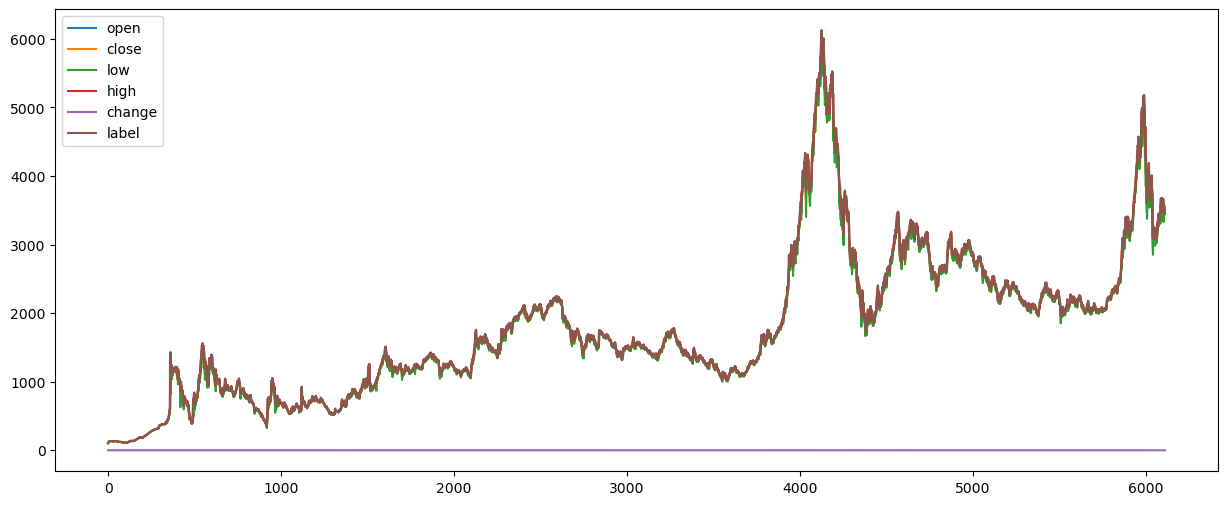

In [7]:
#画出时序特征趋势线
x.drop(['index_code', 'date',"volume","money"], axis=1).plot(figsize=(15, 6))
plt.show()

In [8]:
#转数据类型，设置时间索引
x.index = pd.to_datetime(x['date'])

#按照时间序列进行移窗
df_shift, y = make_forecasting_frame(x["high"], kind="price", max_timeshift=20, rolling_direction=1)

#查看移窗数据
df_shift.head()

#查看移窗数据格式
df_shift.shape

Rolling: 100%|██████████| 50/50 [00:05<00:00,  8.97it/s]


(121970, 4)

In [9]:
#使用tsfresh包进行特征提取，默认为按最大特征提取，默认值ComprehensiveFCParameters
X = extract_features(df_shift, 
                     column_id="id", 
                     column_sort="time",
                     column_value="value", 
                     impute_function=impute,
                     show_warnings=False)

Feature Extraction: 100%|██████████| 50/50 [00:51<00:00,  1.04s/it]


In [10]:
#查看X格式，过滤掉方差为0的自变量
print(X.shape)  #(6108, 794)
X = X.loc[:, X.apply(pd.Series.nunique) != 1] 
print(X.shape) #(6108, 794)

(6108, 783)
(6108, 363)


In [11]:
#将因变量位移一位拼到自变量上
X["feature_last_value"] = y.shift(1)

#因为位移后，会出现第一个变量为空，所以数据从第二行开始截取
X = X.iloc[1:, ]
y = y.iloc[1: ]

#查看自变量X
X.head()

value__variance_larger_than_standard_deviation  \
id 1990-12-24                                             1.0   
   1990-12-25                                             1.0   
   1990-12-26                                             1.0   
   1990-12-27                                             1.0   
   1990-12-28                                             1.0   

               value__has_duplicate_max  value__has_duplicate  \
id 1990-12-24                       0.0                   0.0   
   1990-12-25                       0.0                   0.0   
   1990-12-26                       0.0                   0.0   
   1990-12-27                       0.0                   0.0   
   1990-12-28                       0.0                   0.0   

               value__sum_values  value__abs_energy  value__mean_abs_change  \
id 1990-12-24             213.52         22806.6290                4.740000   
   1990-12-25             328.07         35928.3315                5.080000   
   1990-12-26             448.32         50388.3940                5.286667   
   1990-12-27             573.59         66080.9669                5.220000   
   1990-12-28             698.87         81776.0453                4.178000   

               value__mean_change  value__mean_second_derivative_central  \
id 1990-12-24            4.740000                               0.005556   
   1990-12-25            5.080000                               0.340000   
   1990-12-26            5.286667                               0.240000   
   1990-12-27            5.220000                               0.046667   
   1990-12-28            4.178000                              -0.591250   

               value__median  value__mean  ...  \
id 1990-12-24         106.76   106.760000  ...   
   1990-12-25         109.13   109.356667  ...   
   1990-12-26         111.84   112.080000  ...   
   1990-12-27         114.55   114.718000  ...   
   1990-12-28         117.40   116.478333  ...   

               value__fourier_entropy__bins_5  \
id 1990-12-24                       -0.000000   
   1990-12-25                        0.693147   
   1990-12-26                        1.098612   
   1990-12-27                        1.098612   
   1990-12-28                        1.039721   

               value__fourier_entropy__bins_10  \
id 1990-12-24                        -0.000000   
   1990-12-25                         0.693147   
   1990-12-26                         1.098612   
   1990-12-27                         1.098612   
   1990-12-28                         1.039721   

               value__fourier_entropy__bins_100  \
id 1990-12-24                         -0.000000   
   1990-12-25                          0.693147   
   1990-12-26                          1.098612   
   1990-12-27                          1.098612   
   1990-12-28                          1.386294   

               value__permutation_entropy__dimension_3__tau_1  \
id 1990-12-24                                        1.522955   
   1990-12-25                                       -0.000000   
   1990-12-26                                       -0.000000   
   1990-12-27                                       -0.000000   
   1990-12-28                                       -0.000000   

               value__permutation_entropy__dimension_4__tau_1  \
id 1990-12-24                                         2.18084   
   1990-12-25                                         2.18084   
   1990-12-26                                        -0.00000   
   1990-12-27                                        -0.00000   
   1990-12-28                                        -0.00000   

               value__permutation_entropy__dimension_5__tau_1  \
id 1990-12-24                                        2.512659   
   1990-12-25                                        2.512659   
   1990-12-26                                        2.512659   
   1990-12-27                                       -0.

In [13]:
#使用adaboost模型进行回归预测
ada = AdaBoostRegressor(n_estimators=10)
y_pred = [np.nan] * len(y)

isp = 100   
assert isp > 0

In [14]:
for i in tqdm(range(isp, len(y))):
    
    ada.fit(X.iloc[:i], y[:i])
    y_pred[i] = ada.predict(X.iloc[i, :].values.reshape((1, -1)))[0]

100%|██████████| 6007/6007 [3:03:02<00:00,  1.83s/it]  


In [15]:
y_pred = pd.Series(data=y_pred, index=y.index)

In [16]:
#拼接预测结果和真实结果
ys = pd.concat([y_pred, y], axis = 1).rename(columns = {0: 'pred', 'value': 'true'})

In [18]:
#转数据类型，设置时间序列索引
ys.index = pd.to_datetime([idx[1] for idx in ys.index])
ys.head()

,pred,true
1990-12-24,NaN,114.55
1990-12-25,NaN,120.25
1990-12-26,NaN,125.27
1990-12-27,NaN,125.28
1990-12-28,NaN,126.45


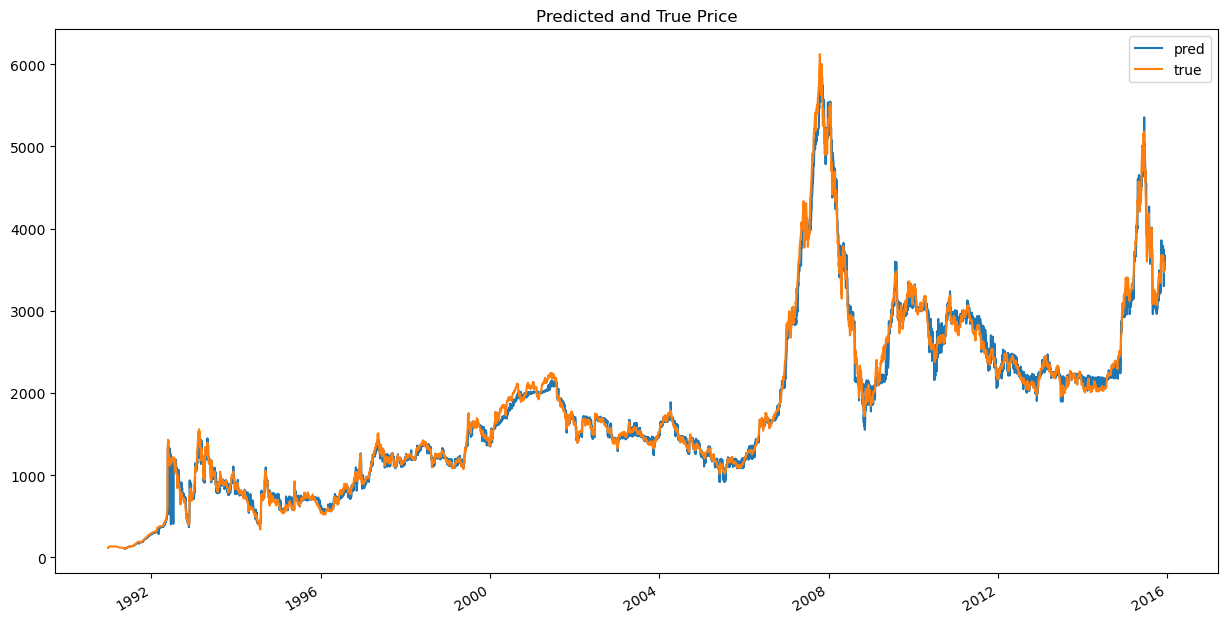

In [19]:
#画出预测结果
ys.plot(figsize=(15, 8))
plt.title('Predicted and True Price')
plt.show()

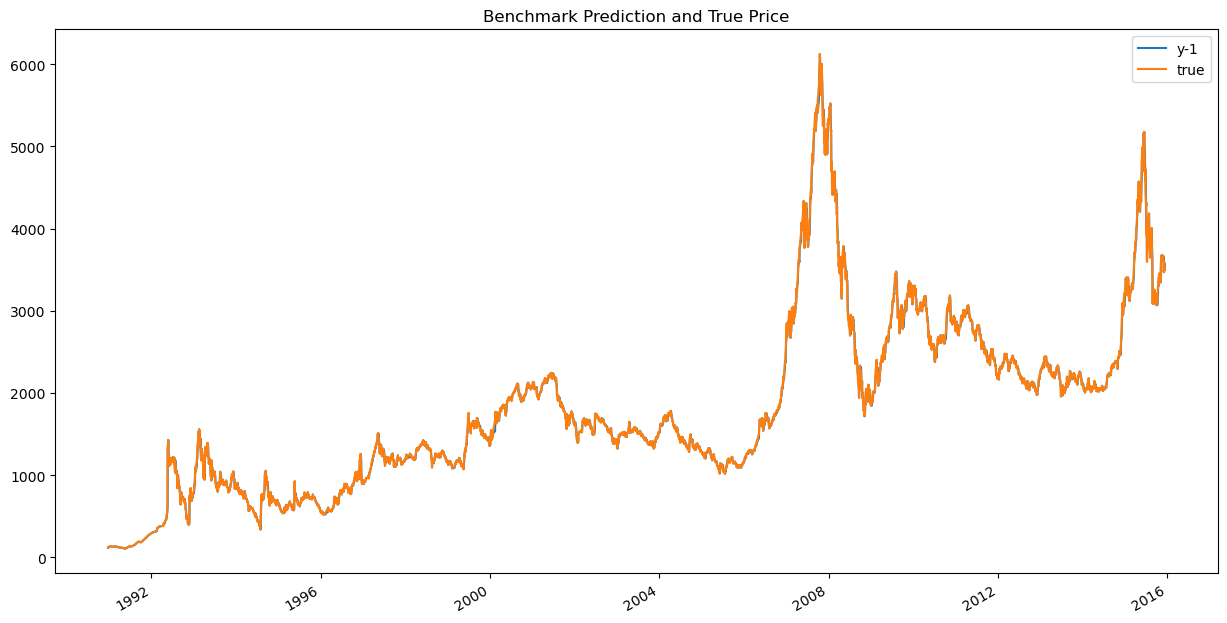

In [20]:
#画出真实值与前一个值的趋势图
ys['y-1'] = ys['true'].shift(1)
ys[['y-1', 'true']].plot(figsize = (15, 8))
plt.title('Benchmark Prediction and True Price')
plt.show()

In [21]:
#输出mae评价指标
print("MAE y-1: \t{}".format(np.mean(np.abs(np.diff(y))[isp-1:] )))
print("MAE ada: \t{}".format(np.mean(np.abs(y_pred - y)[isp:])))
#MAE y-1:        21.03476444148493
#MAE ada:        65.75323360939149

MAE y-1: 	21.03476444148493
MAE ada: 	65.43777515580253


In [ ]:
#由上述mae评价指标看出ada没有达到y-1的基准，
#所以需要迭代开发投入更多特征进入升维操作或者使用更高级别的模型

In [22]:
#输出ada模型重要特征
importances = pd.Series(index=X.columns, data=ada.feature_importances_)
importances.sort_values(ascending=False).head(10)

feature_last_value                       1.0
value__sum_values                        0.0
value__abs_energy                        0.0
value__mean_abs_change                   0.0
value__mean_change                       0.0
value__mean_second_derivative_central    0.0
value__median                            0.0
value__mean                              0.0
value__length                            0.0
value__standard_deviation                0.0
dtype: float64